In [13]:
%matplotlib widget
import torch

from sonar.inference_pipelines.text import (
    TextToEmbeddingModelPipeline,
    EmbeddingToTextModelPipeline,
    TextToTextModelPipeline,
)

import matplotlib.pyplot as plt
import mplcursors

import pandas as pd
import seaborn as sns
import pandas as pd
import numpy as np

import umap

from sklearn.metrics.pairwise import cosine_similarity

In [14]:
text2vec = TextToEmbeddingModelPipeline(
    encoder="text_sonar_basic_encoder", tokenizer="text_sonar_basic_encoder"
)
text2text = TextToTextModelPipeline(
    encoder="text_sonar_basic_encoder",
    decoder="text_sonar_basic_decoder",
    tokenizer="text_sonar_basic_encoder",
)  # tokenizer is attached to both encoder and decoder cards

vec2text = EmbeddingToTextModelPipeline(
    decoder="text_sonar_basic_decoder", tokenizer="text_sonar_basic_encoder"
)

In [15]:
statements = [
    "Joe died in Osaka on Tuesday.",
    "Joe was inside the apartment.",
    "Joe was unhurt in the accident.",
    "After Joe departed, the apartment exploded.",
]
opposite_statements = [
    "Joe came back from Osaka on Tuesday.",
    "Joe was outside the apartment.",
    "Joe was hurt in the accident.",
    "When Joe arrived, the apartment exploded.",
]
output_stmts = text2vec.predict(statements, source_lang="eng_Latn")
output_opst = text2vec.predict(opposite_statements, source_lang="eng_Latn")
original_embeddings = torch.nn.functional.normalize(output_stmts, dim=-1).numpy()
opposite_embeddings = torch.nn.functional.normalize(output_opst, dim=-1).numpy()


print(original_embeddings.shape)
print(opposite_embeddings.shape)

sentence_embeddings = np.concatenate([original_embeddings, opposite_embeddings], axis=0)

difference_vectors = opposite_embeddings - original_embeddings
print(f"Shape of difference vectors: {difference_vectors.shape}")

# --- 3. Compute Pairwise Cosine Similarity ---
# This matrix shows the similarity of each difference vector to every other one.
similarity_matrix = cosine_similarity(difference_vectors)

# For analysis, we can extract the average similarity (ignoring self-similarity)
# We set the diagonal to nan to ignore it in the mean calculation.
np.fill_diagonal(similarity_matrix, np.nan)
mean_similarity = np.nanmean(similarity_matrix)
std_dev_similarity = np.nanstd(similarity_matrix)

print("\n--- Vector Consistency Results ---")
print("Pairwise Similarity Matrix of Difference Vectors:")
print(np.round(similarity_matrix, 2))
print("\n")
print(f"Mean Cosine Similarity: {mean_similarity:.3f}")
print(f"Standard Deviation of Similarity: {std_dev_similarity:.3f}")

if mean_similarity > 0.6 and std_dev_similarity < 0.2:
    print("\nResult: High consistency found. The model may have a stable 'opposition vector'.")
else:
    print("\nResult: Low consistency. The geometric relationship for 'opposition' is not a simple, stable vector.")

(4, 1024)
(4, 1024)
Shape of difference vectors: (4, 1024)

--- Vector Consistency Results ---
Pairwise Similarity Matrix of Difference Vectors:
[[  nan  0.01 -0.11  0.14]
 [ 0.01   nan -0.05 -0.09]
 [-0.11 -0.05   nan  0.03]
 [ 0.14 -0.09  0.03   nan]]


Mean Cosine Similarity: -0.013
Standard Deviation of Similarity: 0.083

Result: Low consistency. The geometric relationship for 'opposition' is not a simple, stable vector.


<Axes: >

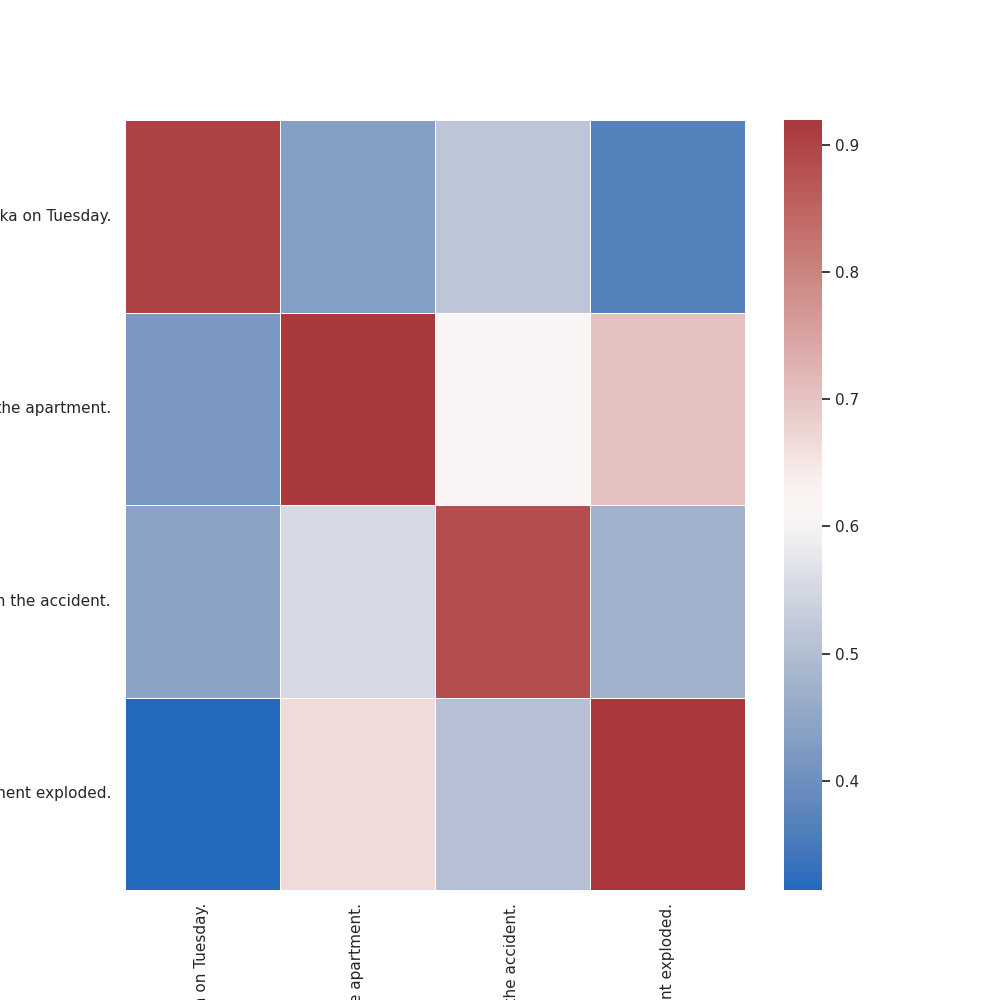

In [4]:


cos_sim = embed_stmt.dot(embed_opst.T)
sim_df = pd.DataFrame(cos_sim, columns=statements, index=opposite_statements)
sns.set_theme(font_scale=0.8)
sns.set_theme(rc={"figure.figsize": (10, 10)})
sns.heatmap(sim_df, cmap="vlag", linewidths=0.5)

In [5]:

df = pd.read_parquet("../data/SONAR_sentences/0_bea5bd311ccf6bef_0_0.parquet")
# print(df.head())
df.columns

Index(['id', 'url', 'title', 'text', 'text_sentences',
       'text_sentences_sonar_emb'],
      dtype='object')

In [6]:

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42  # for reproducibility
)

In [7]:

article_embeddings = df['text_sentences_sonar_emb'].squeeze().to_numpy()
sentence_embeddings = np.stack([sentence for article in article_embeddings for sentence in article])
article = df['text_sentences'].squeeze().to_numpy()
sentences = [sentence for article in article for sentence in article]
print(sentence_embeddings.shape)
print(sentence_embeddings[:5])
print(sentences[:5])

(52896, 1024)
[[-0.00597484  0.00731171 -0.00563276 ...  0.00061534 -0.00146037
   0.00181887]
 [-0.00020585  0.01195663 -0.00329148 ...  0.00407247  0.00580927
   0.01009553]
 [ 0.01393175 -0.00899145 -0.00737793 ...  0.00569317 -0.00042718
   0.00590444]
 [-0.00050881  0.0093087  -0.00343263 ...  0.00732575  0.00356879
   0.0055023 ]
 [ 0.0116464   0.00226866 -0.00436575 ...  0.00450816 -0.00760457
  -0.00155969]]
['Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism.', 'Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations.', 'As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as the libertarian wing of the socialist movement (libertarian socialism).

In [8]:
embedding_2d = reducer.fit(sentence_embeddings)

/home/hukami/anaconda3/envs/llm_lab/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/hukami/anaconda3/envs/llm_lab/lib/python3.11/site-packages/mplcursors/_pick_info.py:56: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  paths = scatter.__wrapped__(*args, **kwargs)


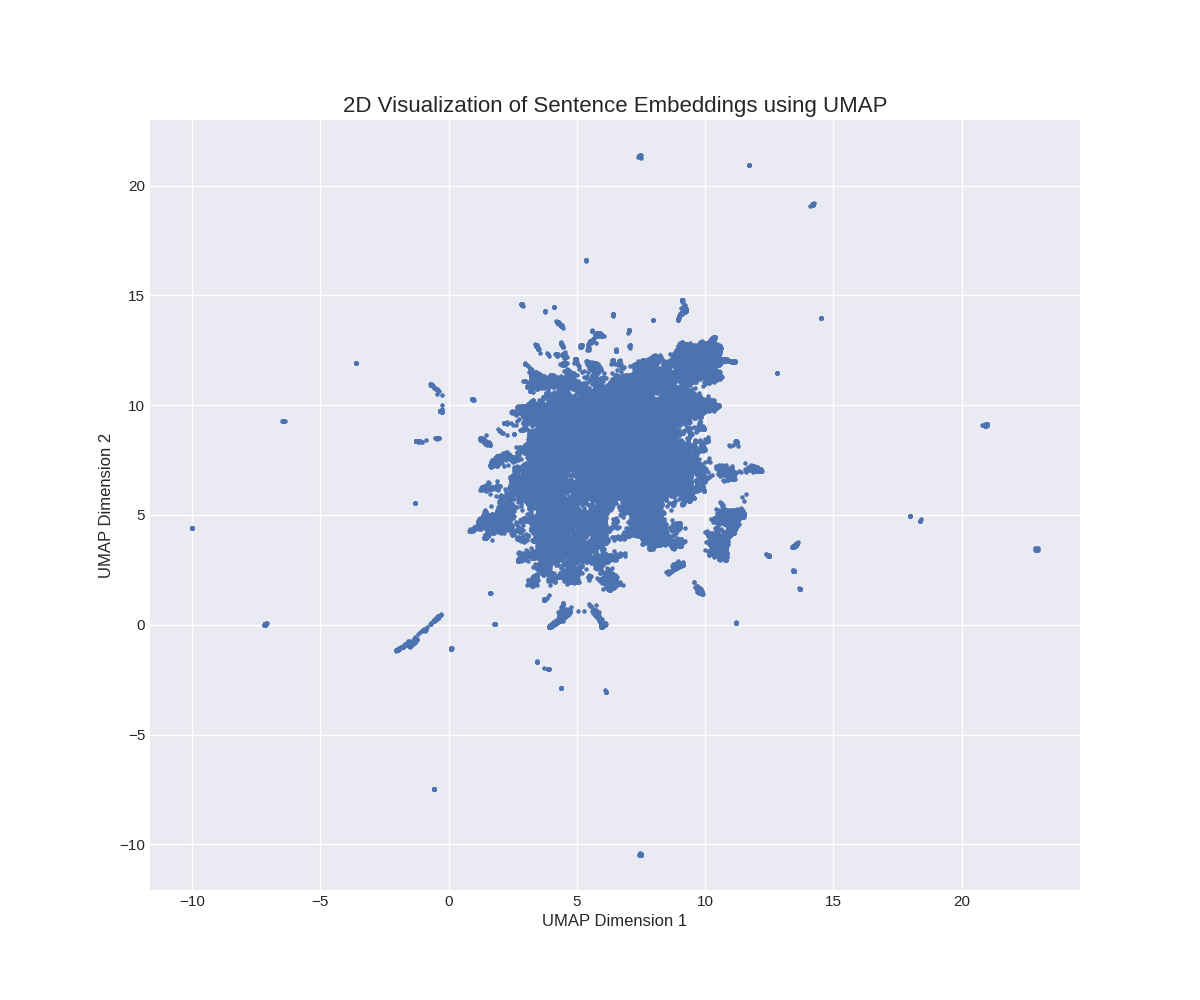

In [9]:

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(12, 10))
embedding_2d = reducer.fit_transform(sentence_embeddings)

# Create a scatter plot of the 2D embeddings.
# Use the labels to color the points if you have them.
scatter = ax.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    cmap='Spectral',  # A visually distinct color map
    s=5  # Marker size
)

# Add titles and labels for clarity
ax.set_title('2D Visualization of Sentence Embeddings using UMAP', fontsize=16)
ax.set_xlabel('UMAP Dimension 1', fontsize=12)
ax.set_ylabel('UMAP Dimension 2', fontsize=12)

# Assume 'sentences' is a list of strings, one per point
cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_add(sel):
    idx = sel.index
    sel.annotation.set_text(sentences[idx])
plt.show()

/home/hukami/anaconda3/envs/llm_lab/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


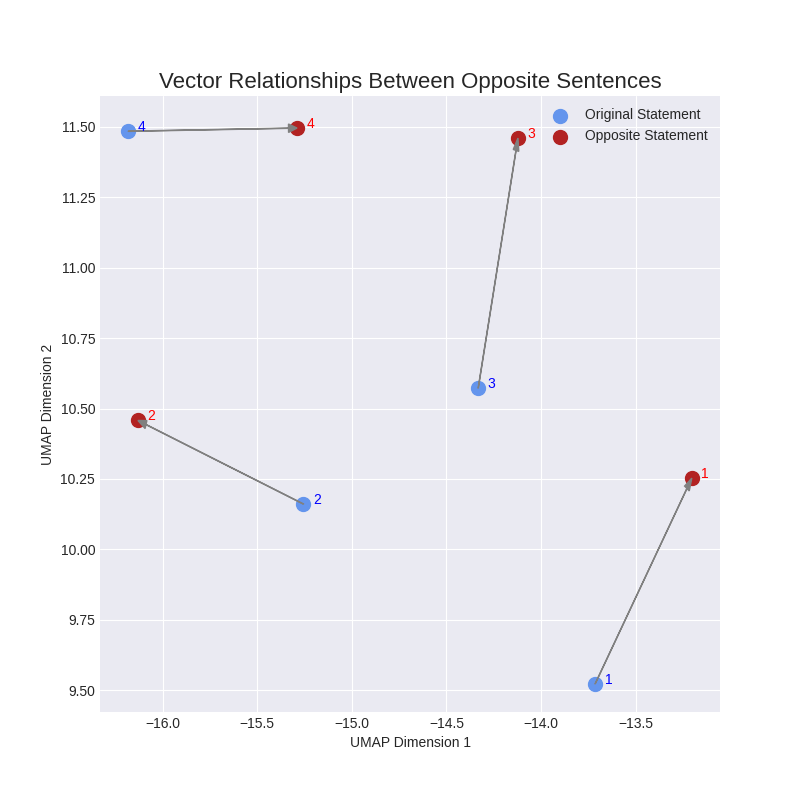

In [ ]:
reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, metric='cosine', random_state=42)


num_pairs = len(statements)
original_2d = embedding_2d[:num_pairs]
opposite_2d = embedding_2d[num_pairs:]

plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(8, 8))
# Plot the points
# Original statements will be blue circles
ax.scatter(original_2d[:, 0], original_2d[:, 1], c='cornflowerblue', s=100, label='Original Statement')
# Opposite statements will be red circles
ax.scatter(opposite_2d[:, 0], opposite_2d[:, 1], c='firebrick', s=100, label='Opposite Statement')

# # Draw arrows from original to opposite
for i in range(num_pairs):
    ax.arrow(
        original_2d[i, 0], original_2d[i, 1],
        opposite_2d[i, 0] - original_2d[i, 0],
        opposite_2d[i, 1] - original_2d[i, 1],
        head_width=0.03, length_includes_head=True,
        linewidth=1, color='gray'
    )
    # Annotate with the pair number
    ax.text(original_2d[i, 0] + 0.05, original_2d[i, 1], f'{i+1}', c='blue')
    ax.text(opposite_2d[i, 0] + 0.05, opposite_2d[i, 1], f'{i+1}', c='red')


ax.set_title('Vector Relationships Between Opposite Sentences', fontsize=16)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend()
ax.grid(True)

plt.show()
